# TP2 (a completer) : Arbre de decision — *Pima Diabetes*

Remplacez chaque `...` et chaque `# TODO`. Le corrige
(`../notebooks/TP2_arbre_decision.ipynb`) applique la **meme demarche sur un
AUTRE dataset (Breast Cancer)** : la structure est identique, seules les donnees
et les colonnes changent : a vous d'adapter.

**Objectif.** Predire si une patiente est **diabetique** avec un arbre
**interpretable**, et evaluer en privilegiant le **rappel sur les cas diabetiques**.

In [2]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [3]:
from sklearn.datasets import fetch_openml
ds = fetch_openml(name="diabetes", version=1, as_frame=True)   # telecharge une fois puis cache
X = ds.data                                  # 8 mesures medicales (preg, plas, pres, ...)
y = (ds.target == "tested_positive").astype(int)
CLASSES = ["non_diabetique", "diabetique"]   # 0 = negatif, 1 = positif
print(X.shape, CLASSES)

(768, 8) ['non_diabetique', 'diabetique']


## 1. Exploration
**Consigne.** Affichez la repartition des classes (combien de diabetiques / non).

In [4]:
# Repartition de y : combien de diabetiques / non diabetiques
y.map({0: CLASSES[0], 1: CLASSES[1]}).value_counts()

class
non_diabetique    500
diabetique        268
Name: count, dtype: int64

## 2. Modelisation
**Consigne.** Separez en train/test (25% test, `stratify=y`, `random_state=42`),
puis entrainez un `DecisionTreeClassifier` (`max_depth=3`, `min_samples_leaf=10`).

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# On cree l'arbre puis on l'entraine sur les donnees d'entrainement
arbre = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=42)
arbre.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

## 3. Evaluation
**Consigne.** Affichez l'accuracy train et test, le `classification_report`
(avec `target_names=CLASSES`) et la **matrice de confusion**. Commentez le
**rappel** de la classe `diabetique`.

RER E (Train) Accuracy :  0.7829861111111112
Test Accuracy  :  0.7135416666666666
                precision    recall  f1-score   support

non_diabetique       0.75      0.84      0.79       125
    diabetique       0.62      0.48      0.54        67

      accuracy                           0.71       192
     macro avg       0.68      0.66      0.67       192
  weighted avg       0.70      0.71      0.70       192



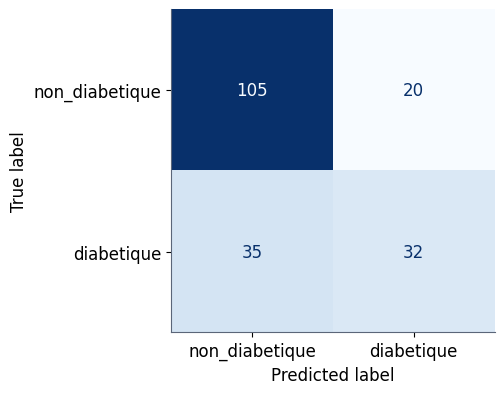

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("RER E (Train) Accuracy : ", arbre.score(X_train, y_train))
print("Test Accuracy  : ", arbre.score(X_test, y_test))

y_pred = arbre.predict(X_test)
print(classification_report(y_test, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.show()

## 4. Visualisation
**Consigne.** Tracez l'arbre (`plot_tree`) puis l'**importance des variables**
(barres horizontales des `feature_importances_` non nulles).

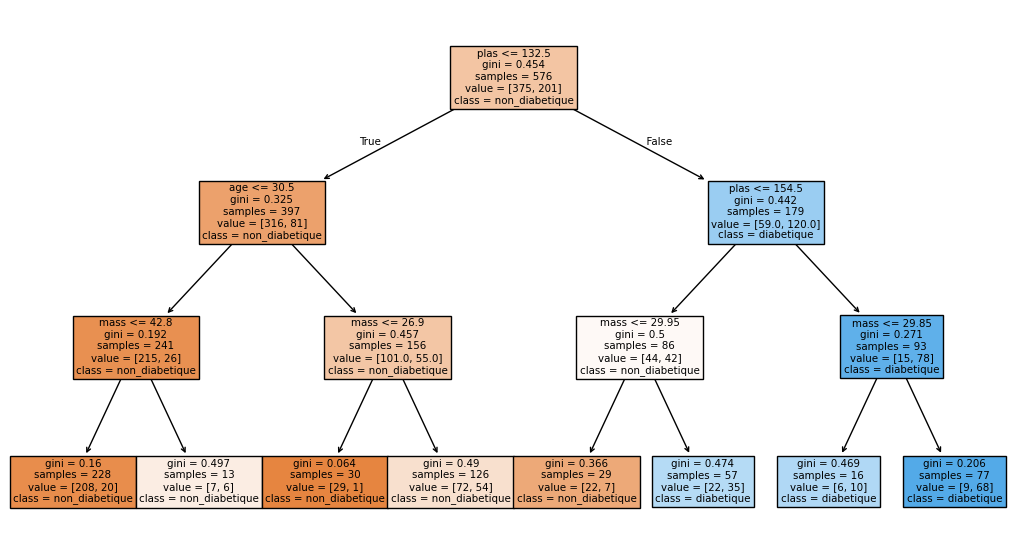

In [7]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(13, 7))
plot_tree(arbre, feature_names=X.columns, class_names=CLASSES, filled=True, ax=ax)
plt.show()

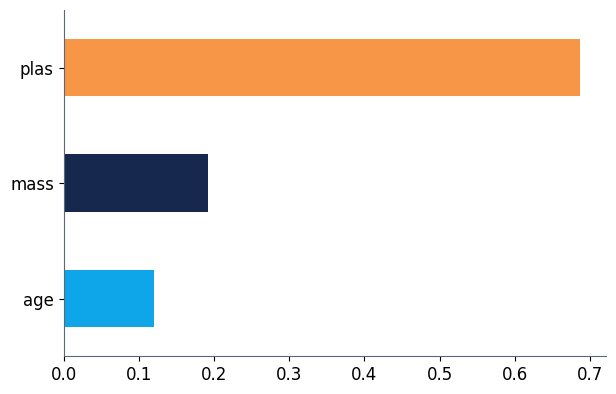

In [8]:
imp = pd.Series(arbre.feature_importances_, index=X.columns)
imp = imp[imp > 0].sort_values()

imp.plot.barh(color=PALETTE)
plt.show()

## 5. Prise de decision
**Consigne.** Sur 5 cas du test, affichez diagnostic reel, predit et
`predict_proba` de la classe diabetique.

In [9]:
ech = X_test.head(5)

# Prediction (0 ou 1) et probabilite d'etre diabetique
pred = arbre.predict(ech)
proba = arbre.predict_proba(ech)[:, 1]

# On construit le tableau de comparaison
comparatif = pd.DataFrame()
comparatif["reel"] = y_test.head(5).values
comparatif["predit"] = pred
comparatif["proba_diabetique"] = proba.round(2)

# On remplace les 0 et 1 par les vrais noms (plus lisible)
comparatif["reel"] = comparatif["reel"].map({0: CLASSES[0], 1: CLASSES[1]})
comparatif["predit"] = comparatif["predit"].map({0: CLASSES[0], 1: CLASSES[1]})

comparatif

,reel,predit,proba_diabetique
0,diabetique,non_diabetique,0.43
1,non_diabetique,non_diabetique,0.09
2,non_diabetique,non_diabetique,0.09
3,diabetique,diabetique,0.61
4,diabetique,diabetique,0.88


## A rendre
- Accuracy test + lecture de la matrice de confusion.
- Le rappel sur `diabetique` et pourquoi il est prioritaire ici.
- Les 2-3 variables les plus determinantes.

**Bonus.** Faites varier `max_depth` (2, 3, 6, None) : ou commence le surapprentissage ?

In [10]:

for profondeur in [2, 3, 6, None]:
    a = DecisionTreeClassifier(max_depth=profondeur, min_samples_leaf=10, random_state=42)
    a.fit(X_train, y_train)

    RER_A = a.score(X_train, y_train)
    Test  = a.score(X_test, y_test)

    print("max_depth =", profondeur,
          "| train RER A =", round(RER_A, 3),
          "| test =", round(Test, 3))

max_depth = 2 | train RER A = 0.76 | test = 0.708
max_depth = 3 | train RER A = 0.783 | test = 0.714
max_depth = 6 | train RER A = 0.83 | test = 0.755
max_depth = None | train RER A = 0.835 | test = 0.766
